# Bug-Fix Agentic-PRs — Temporal Findings (Quick Trio)

Follow-up to *"Understanding the Rejection of Fixes Generated by Agentic Pull Requests"* (MSR '26),
adding a **time** dimension on the [`mabujadallah/GitHub-Agentic-PR-Dataset`](https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset).

**Scope:** `fix_prs_only.parquet` — 422,618 bug-fix PRs (`type=fix`), span **2024-12 → 2026-02 (15 months)**.
**Groups:** Agent (`is_agent==True`, 121,832: Claude_Code / Cursor / Copilot / Devin) vs Human (`is_agent==False`, 300,786).

Research questions in this notebook:
- **RQ1a** — does the rejection rate change over time?
- **RQ1b** — does code churn (fix size) change over time?
- **RQ2a** — do people switch which agent they use to fix bugs?
- **RQ6** — does shipping a test correlate with acceptance?

## How everything is calculated (shared definitions)

- **Month** = first 7 chars of `created_at` (`YYYY-MM`) = the PR's creation month.
- **Rejected** = `state=='closed'` **and** `merged_at` is null/empty (closed without merge).
- **Merged** = `merged_at` present. **Decided/closed** = `state=='closed'` (merged + rejected).
- **Rejection rate** = rejected / closed (open PRs excluded so undecided recent PRs don't deflate it).
- **Code churn (per PR)** = `sum(additions + deletions)` over all the PR's commit-file rows.
- **has_test** = any changed file path matches the test regex (defined below).
- **Trend test** = Spearman correlation between month-index (0..N) and the monthly value.
- *Caveat:* the most recent month is right-censored (slow merges still pending) — read the last point loosely.

In [ ]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, chi2_contingency
%matplotlib inline
warnings.filterwarnings("ignore")

BASE = r"C:\Users\Mahmoudabujadallah\final_agantic_bugfixes"
DATA = os.path.join(BASE, "data")
AGENTS = ["Claude_Code", "Cursor", "Copilot", "Devin"]

prs = pd.read_parquet(os.path.join(DATA, "fix_prs_only.parquet"),
                      columns=["id","state","created_at","merged_at","is_agent","agent"])
prs["month"] = prs["created_at"].str.slice(0, 7)
prs = prs[prs["month"].notna() & (prs["month"] != "")]
prs["closed"]   = prs["state"] == "closed"
mna             = prs["merged_at"].isna() | prs["merged_at"].astype(str).isin(["", "NaT", "None"])
prs["merged"]   = ~mna
prs["rejected"] = prs["closed"] & ~prs["merged"]
prs["grp"]      = np.where(prs["is_agent"], "Agent", "Human")
months = sorted(prs["month"].unique())
xi = np.arange(len(months))
print(f"{len(prs):,} fix PRs | {months[0]}..{months[-1]} ({len(months)} months) | "
      f"agent={int(prs['is_agent'].sum()):,} human={int((~prs['is_agent']).sum()):,}")

## RQ1a — Does the rejection rate change over time?

**Answer:** The **agent–human gap closes.** Agents start higher and spike to **23% (Mar 2025)**, then flatten
(~16%, no significant trend, Spearman ρ≈0.04, p≈0.89). Humans rise significantly (**ρ≈0.93, p<0.001**) from ~12% to ~18%.
By late 2025 human rejection ≈ or exceeds agent — agents effectively *caught up*.

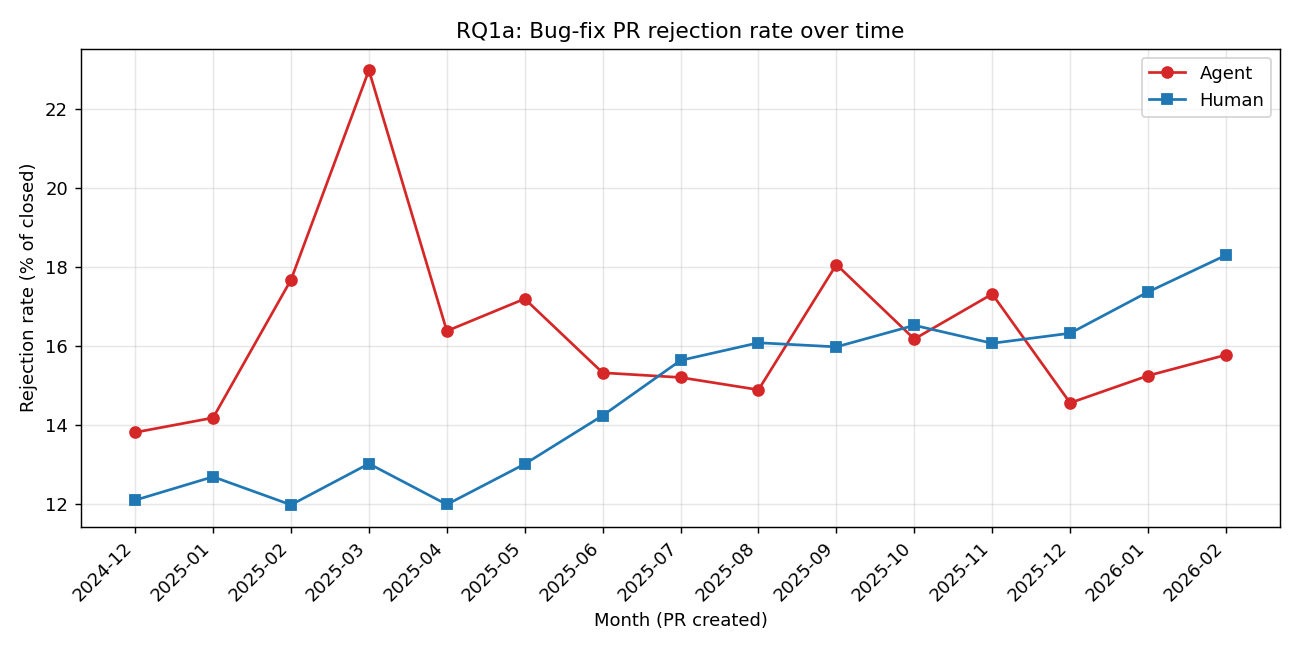

In [ ]:
def monthly_rate(df):
    g = df[df["closed"]].groupby("month")
    return (100 * g["rejected"].sum() / g["rejected"].count()).reindex(months)

agent_rej = monthly_rate(prs[prs.grp == "Agent"])
human_rej = monthly_rate(prs[prs.grp == "Human"])
ra, pa = spearmanr(xi, agent_rej.values); rh, ph = spearmanr(xi, human_rej.values)
print(f"Agent: mean {agent_rej.mean():.1f}% range {agent_rej.min():.1f}-{agent_rej.max():.1f}% | trend rho={ra:.2f} p={pa:.3f}")
print(f"Human: mean {human_rej.mean():.1f}% | trend rho={rh:.2f} p={ph:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(months, agent_rej.values, "o-", label="Agent", color="#d62728")
plt.plot(months, human_rej.values, "s-", label="Human", color="#1f77b4")
plt.ylabel("Rejection rate (% of closed)"); plt.xlabel("Month (PR created)")
plt.title("RQ1a: Bug-fix PR rejection rate over time"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ2a — Do people switch which agent they use to fix bugs?

**Answer: Yes, the mix shifts a lot.** Claude_Code + Cursor dominated early (~90% in Dec 2024).
**Copilot was ~2% until May 2025, then surged to ~28–33%** (coding-agent launch). **Devin faded** from a 27% peak (Apr 2025) to ~5%.

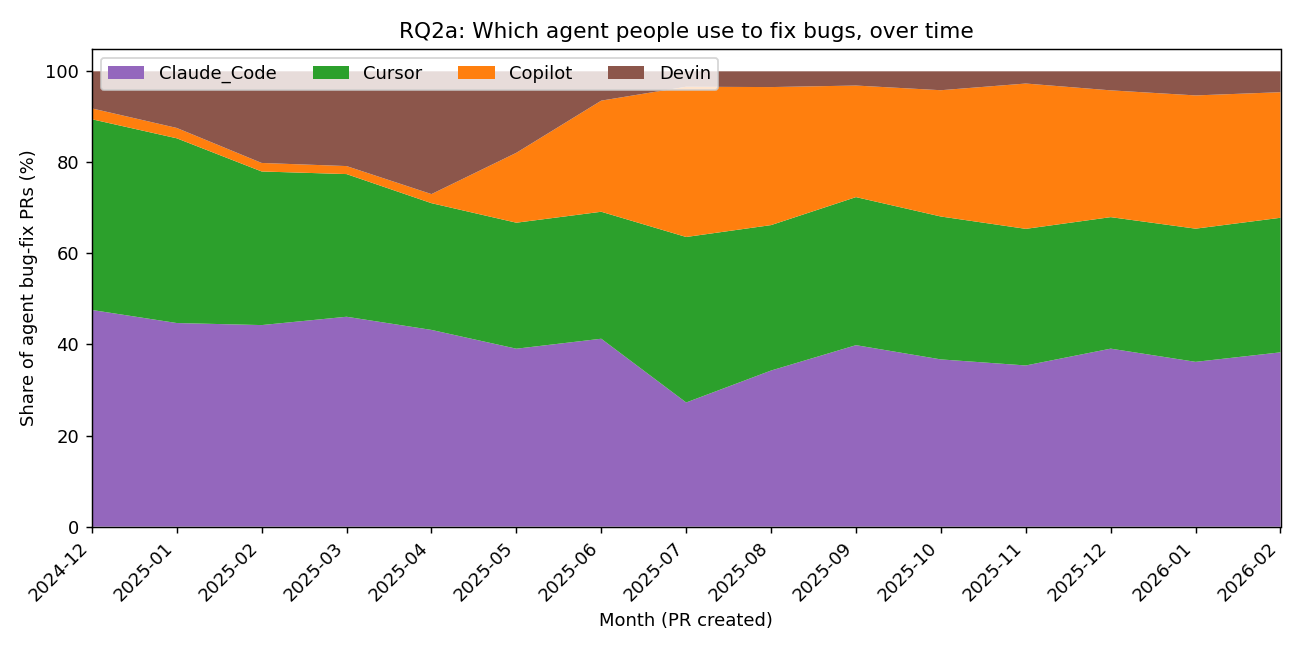

In [ ]:
agt = prs[prs.is_agent]
piv = agt[agt.agent.isin(AGENTS)].pivot_table(index="month", columns="agent",
        values="id", aggfunc="count", fill_value=0).reindex(months).fillna(0)
share = piv.div(piv.sum(axis=1), axis=0) * 100
for a in AGENTS:
    print(f"{a:12s}: {share[a].iloc[0]:4.0f}% -> {share[a].iloc[-1]:4.0f}%  (peak {share[a].max():.0f}% in {share[a].idxmax()})")

plt.figure(figsize=(10, 5))
plt.stackplot(months, [share[a].values for a in AGENTS], labels=AGENTS,
              colors=["#9467bd", "#2ca02c", "#ff7f0e", "#8c564b"])
plt.ylabel("Share of agent bug-fix PRs (%)"); plt.xlabel("Month (PR created)")
plt.title("RQ2a: Which agent people use to fix bugs, over time")
plt.xticks(rotation=45, ha="right"); plt.legend(loc="upper left", ncol=4); plt.margins(x=0)
plt.tight_layout(); plt.show()

## Load commit-file details (for churn + tests)

`fix_pr_commit_details.parquet` has one row per changed file per commit. We aggregate to the PR level:
**churn** = sum of added+deleted lines; **has_test** = any changed path looks like a test file.

In [ ]:
det = pd.read_parquet(os.path.join(DATA, "fix_pr_commit_details.parquet"),
                      columns=["pr_id", "filename", "additions", "deletions"])
det["lines"] = det["additions"].fillna(0) + det["deletions"].fillna(0)
churn = det.groupby("pr_id")["lines"].sum().rename("churn")

TEST_RE = re.compile(r"(^|/)(tests?|__tests__|spec)(/|\.)|(_test\.|test_|\.test\.|\.spec\.|_spec\.|\.tests\.)", re.I)
det["is_test"] = det["filename"].fillna("").map(lambda f: bool(TEST_RE.search(f)))
has_test = det.groupby("pr_id")["is_test"].any().rename("has_test")

prs = prs.merge(churn, left_on="id", right_index=True, how="left")
prs = prs.merge(has_test, left_on="id", right_index=True, how="left")
cov = prs["churn"].notna().mean() * 100
prs["churn"] = prs["churn"].fillna(0)
prs["has_test"] = prs["has_test"].fillna(False).astype(bool)
print(f"commit-detail coverage: {cov:.1f}% of fix PRs have file rows (rest treated as 0 churn / no test)")

## RQ1b — Does code churn (fix size) change over time?

**Answer:** Agent fixes are much larger than human (**median 33 vs 6 lines**) and follow an **inverted-U**:
rising to **~76 lines (Jul 2025)** then shrinking toward ~10 — agents trending to tighter fixes
(monotonic trend n.s. because of the hump; last month partly censored).

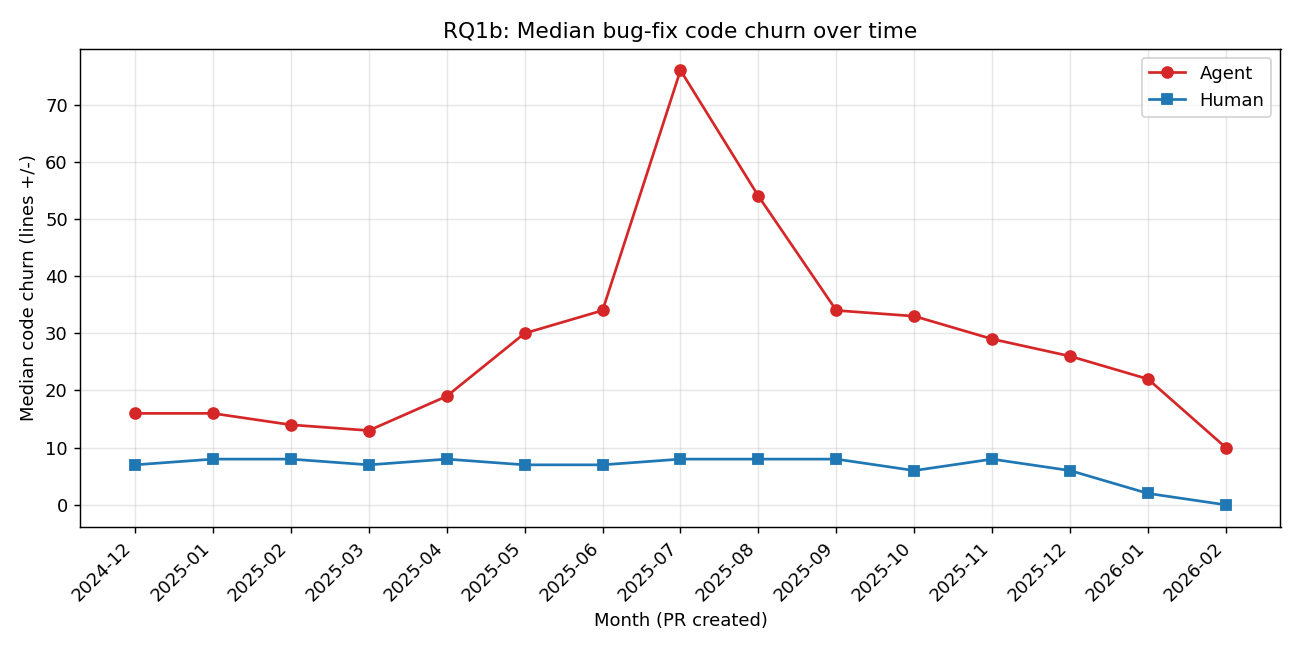

In [ ]:
def med_churn(df): return df.groupby("month")["churn"].median().reindex(months)
agent_ch, human_ch = med_churn(prs[prs.grp=="Agent"]), med_churn(prs[prs.grp=="Human"])
rac, pac = spearmanr(xi, agent_ch.values)
print(f"Agent median churn overall: {prs[prs.grp=='Agent'].churn.median():.0f} | Human: {prs[prs.grp=='Human'].churn.median():.0f}")
print(f"Agent monthly: {agent_ch.iloc[0]:.0f} -> peak {agent_ch.max():.0f} ({agent_ch.idxmax()}) -> {agent_ch.iloc[-1]:.0f} | trend rho={rac:.2f} p={pac:.3f}")

plt.figure(figsize=(10, 5))
plt.plot(months, agent_ch.values, "o-", label="Agent", color="#d62728")
plt.plot(months, human_ch.values, "s-", label="Human", color="#1f77b4")
plt.ylabel("Median code churn (lines +/-)"); plt.xlabel("Month (PR created)")
plt.title("RQ1b: Median bug-fix code churn over time"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ6 — Does shipping a test correlate with acceptance?

**Answer: Counterintuitively, no.** PRs that include a test are rejected **more** — agents **+2.1 pts**
(17.7% vs 15.6%, χ² p≈5e-15), humans **+1.7 pts** (16.3% vs 14.6%, χ² p≈7e-25). Test-inclusion rose **14%→21%** for agents.
Likely because test-bearing PRs are larger/harder to review, or tests surface failures — worth a churn-controlled check before relying on it.

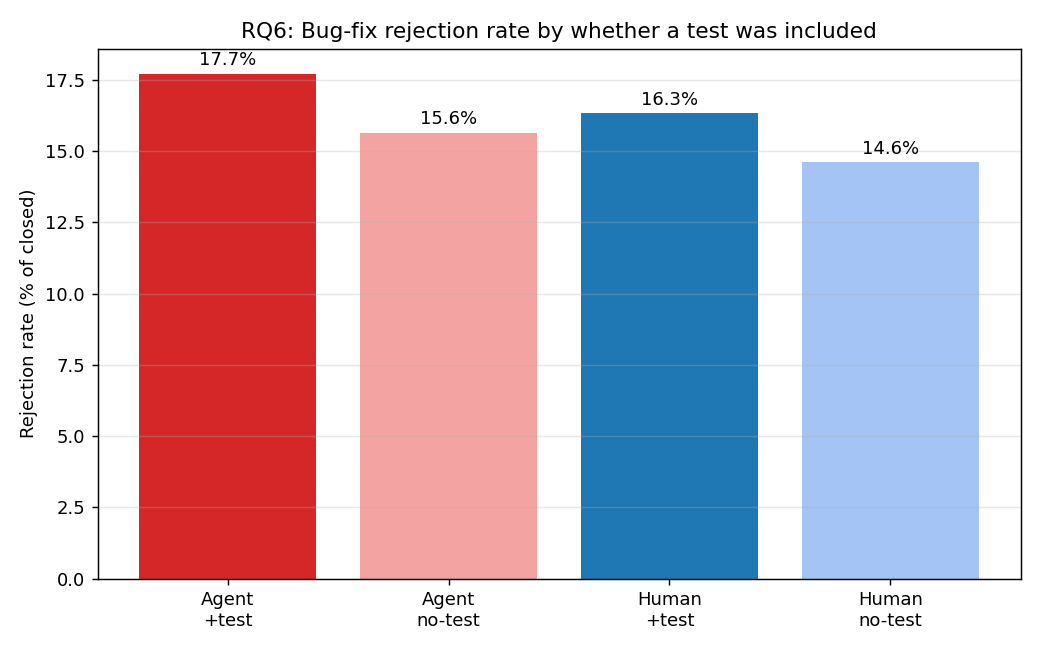

In [ ]:
def rej_rate(df):
    d = df[df.closed]; return (100 * d["rejected"].mean(), len(d))

rows = []
for g in ["Agent", "Human"]:
    sub = prs[prs.grp == g]
    rt, nt = rej_rate(sub[sub.has_test]); rn, nn = rej_rate(sub[~sub.has_test])
    c = sub[sub.closed]; _, p, _, _ = chi2_contingency(pd.crosstab(c.has_test, c.rejected))
    rows.append((g, rt, nt, rn, nn, p))
    print(f"{g}: +test {rt:.1f}% (n={nt:,}) | no-test {rn:.1f}% (n={nn:,}) | diff {rt-rn:+.1f}pts | chi2 p={p:.2e}")

labels = ["Agent\n+test", "Agent\nno-test", "Human\n+test", "Human\nno-test"]
vals = [rows[0][1], rows[0][3], rows[1][1], rows[1][3]]
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, vals, color=["#d62728", "#f4a3a3", "#1f77b4", "#a3c4f4"])
for b, v in zip(bars, vals): plt.text(b.get_x()+b.get_width()/2, v+0.3, f"{v:.1f}%", ha="center")
plt.ylabel("Rejection rate (% of closed)"); plt.title("RQ6: Rejection rate by whether a test was included")
plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

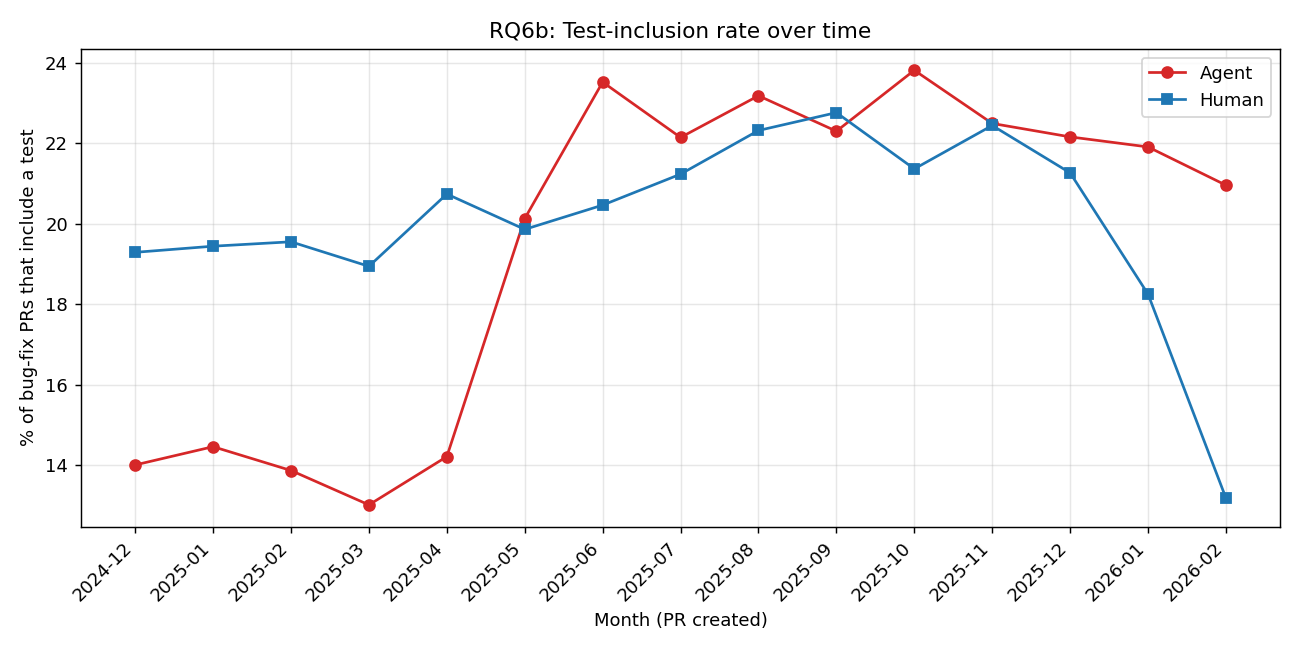

In [ ]:
ti_a = prs[prs.grp=="Agent"].groupby("month")["has_test"].mean().reindex(months)*100
ti_h = prs[prs.grp=="Human"].groupby("month")["has_test"].mean().reindex(months)*100
plt.figure(figsize=(10, 5))
plt.plot(months, ti_a.values, "o-", label="Agent", color="#d62728")
plt.plot(months, ti_h.values, "s-", label="Human", color="#1f77b4")
plt.ylabel("% of bug-fix PRs that include a test"); plt.xlabel("Month (PR created)")
plt.title("RQ6b: Test-inclusion rate over time"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## RQ2b — Model-substitution / relay: does switching agent rescue a failed fix?

We link fix PRs to the issue they claim to close (GitHub keywords `fixes/closes/resolves #N`) and group attempts per issue.
**~18%** of fix PRs carry such a link; **6,311 issues** got ≥2 fix attempts.

**Answer — switching agents is rare; people mostly retry the same agent or take over themselves.**
Of **653** issues whose *first* fix was an agent PR that got rejected, **69.7% were eventually fixed**, but the rescuer was:
**same agent retry 44.9%**, **human takeover 23.0%**, and a **different agent (true substitution) only 1.8%** (12 cases); **30.3% never recovered.**
So the intuitive "swap to a better model" pattern is almost absent in the wild — a finding in itself.

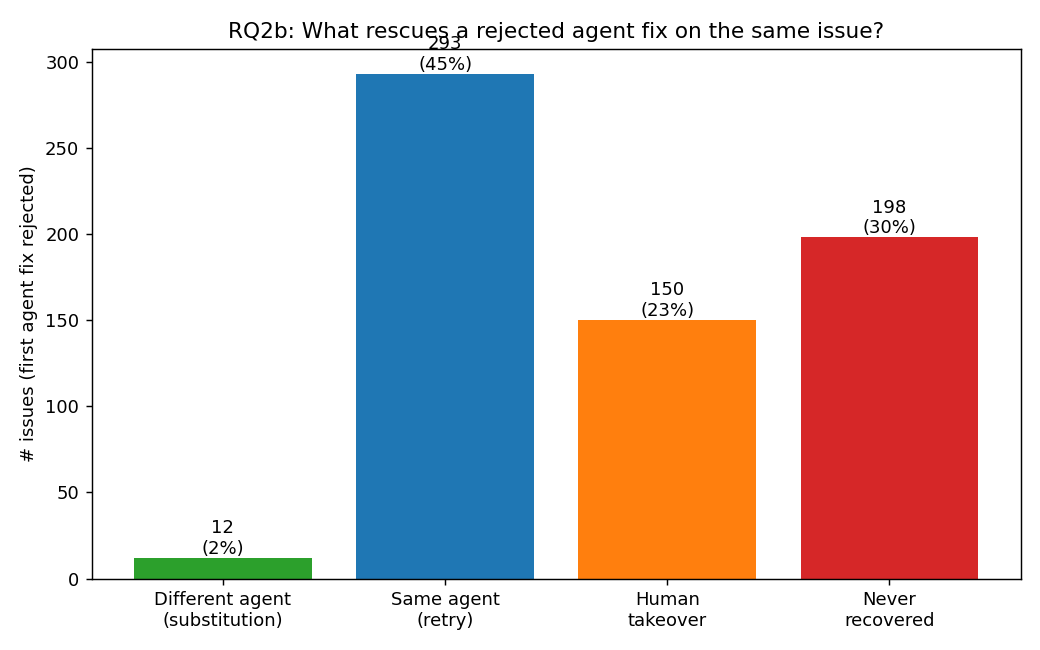

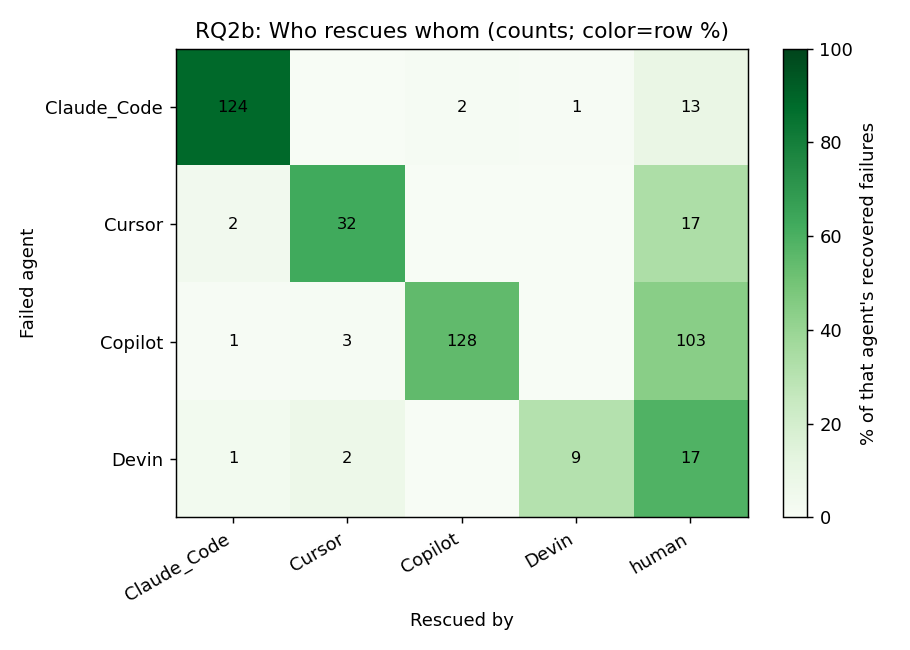

In [ ]:
rel = pd.read_parquet(os.path.join(DATA, "fix_prs_only.parquet"),
        columns=["id","title","body","state","created_at","merged_at","repo_id","is_agent","agent"])
_mna = rel["merged_at"].isna() | rel["merged_at"].astype(str).isin(["", "NaT", "None"])
rel["merged"]   = ~_mna
rel["rejected"] = (rel["state"] == "closed") & ~rel["merged"]
rel["label"]    = np.where(rel["is_agent"], rel["agent"], "human")
RESCUERS = AGENTS + ["human"]

KEY = re.compile(r"(?:close[sd]?|fix(?:e[sd])?|resolve[sd]?)\s*:?\s+#(\d+)", re.I)
rel["refs"] = [set(int(m) for m in KEY.findall(f"{t or ''}\n{b or ''}"))
               for t, b in zip(rel["title"], rel["body"])]
cov = (rel["refs"].map(len) > 0).mean() * 100

recs = [(r.repo_id, iss, r.created_at, r.label, r.is_agent, r.merged, r.rejected)
        for r in rel.itertuples(index=False) for iss in r.refs]
ex = pd.DataFrame(recs, columns=["repo_id","issue","created_at","label","is_agent","merged","rejected"]).sort_values("created_at")
g = ex.groupby(["repo_id","issue"]); sizes = g.size(); multi = sizes[sizes >= 2].index
print(f"{cov:.1f}% of fix PRs reference an issue | {len(multi):,} issues with >=2 fix attempts")

same = diff = human = norec = n_failed = 0
matrix = pd.DataFrame(0, index=AGENTS, columns=RESCUERS)
for key in multi:
    sub = g.get_group(key); first = sub.iloc[0]
    if not (first.is_agent and first.rejected): continue
    n_failed += 1; later = sub.iloc[1:]; win = later[later["merged"]]
    if len(win) == 0: norec += 1; continue
    resc = win.iloc[0]["label"]
    if resc == first.label: same += 1
    elif resc == "human":   human += 1
    else:                   diff += 1
    if first.label in AGENTS: matrix.loc[first.label, resc] += 1
rec = same + diff + human
print(f"first agent fix rejected: {n_failed} | recovered {100*rec/n_failed:.1f}% | "
      f"substitution {diff}, retry {same}, human {human}, never {norec}")

labels = ["Different agent\n(substitution)","Same agent\n(retry)","Human\ntakeover","Never\nrecovered"]
vals = [diff, same, human, norec]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, vals, color=["#2ca02c","#1f77b4","#ff7f0e","#d62728"])
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v, f"{v}\n({100*v/n_failed:.0f}%)", ha="center", va="bottom")
plt.ylabel("# issues (first agent fix rejected)"); plt.title("RQ2b: What rescues a rejected agent fix?")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.imshow(matrix.values, cmap="Greens", aspect="auto")
plt.xticks(range(len(RESCUERS)), RESCUERS, rotation=30, ha="right"); plt.yticks(range(len(AGENTS)), AGENTS)
for i in range(len(AGENTS)):
    for j in range(len(RESCUERS)):
        if matrix.values[i,j]: plt.text(j, i, matrix.values[i,j], ha="center", va="center")
plt.xlabel("Rescued by"); plt.ylabel("Failed agent"); plt.title("RQ2b: Who rescues whom (counts)")
plt.colorbar(label="count"); plt.tight_layout(); plt.show()

## RQ4 — Fix durability: do merged fixes get reverted?

We collect every fix PR's commit SHAs, then scan **all** PR commit messages for `This reverts commit <sha>`;
a merged fix is "reverted" if one of its commits is reverted by a different PR.

**Answer — agent fixes are reverted *less* than human fixes.** Agent merged fixes: **0.052%** reverted (51/97,374)
vs human **0.123%** (303/245,530). Copilot & Devin are lowest (~0.02%), Claude_Code & Cursor ~0.06%.
Reverts are rare overall (fixes are durable). *Caveat:* agent fixes are more recent, so they've had less time to be reverted —
part of the gap is survivorship/time bias; this is a lower bound (only PR-routed reverts are visible).

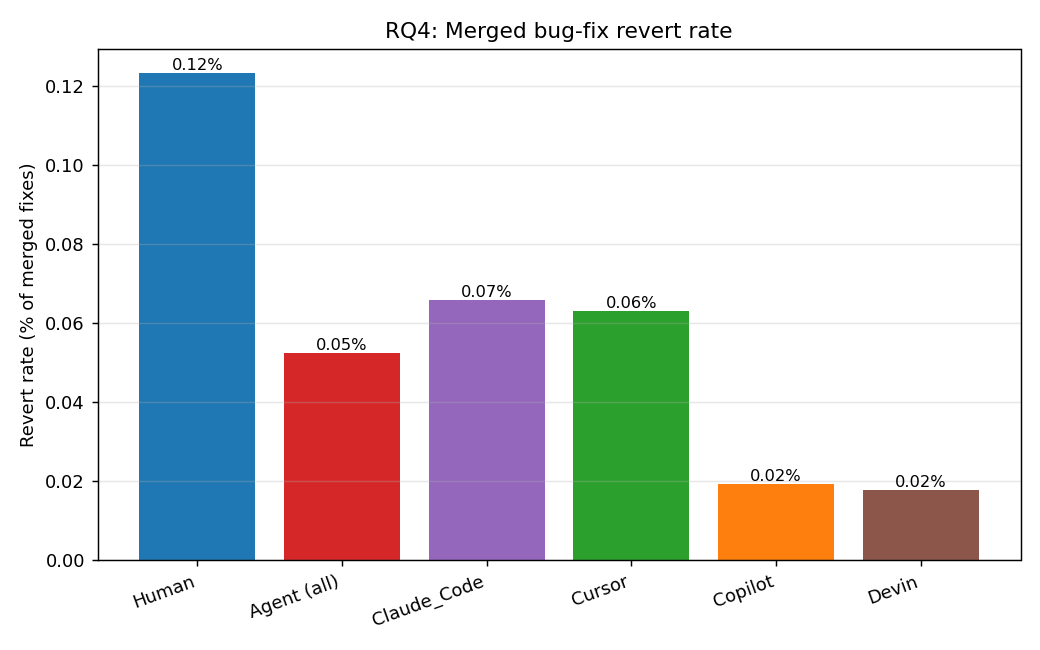

In [ ]:
fix_ids = set(rel["id"].tolist())
com = pd.read_parquet(os.path.join(DATA, "pr_commits.parquet"), columns=["sha","pr_id","message"])
fixcom = com[com["pr_id"].isin(fix_ids)]
sha_to_pr = dict(zip(fixcom["sha"].str.slice(0, 12), fixcom["pr_id"]))

REV = re.compile(r"reverts commit ([0-9a-f]{7,40})", re.I)
reverted_pr = {}
for pr_id, msg in zip(com["pr_id"], com["message"]):
    if not isinstance(msg, str) or "revert" not in msg.lower(): continue
    for ref in REV.findall(msg):
        orig = sha_to_pr.get(ref[:12])
        if orig is not None and orig != pr_id:
            reverted_pr.setdefault(orig, pr_id)
rev_ids = set(reverted_pr)

merged = rel[rel["merged"]].copy(); merged["reverted"] = merged["id"].isin(rev_ids)
def rate(df): return (100*df["reverted"].mean(), int(df["reverted"].sum()), len(df))
ra, na, ta = rate(merged[merged.is_agent]); rh, nh, th = rate(merged[~merged.is_agent])
per_agent = {a: rate(merged[merged.agent == a]) for a in AGENTS}
print(f"Agent reverted {na}/{ta} = {ra:.3f}% | Human {nh}/{th} = {rh:.3f}%")
for a,(r,n,t) in per_agent.items(): print(f"  {a}: {n}/{t} = {r:.3f}%")

labels = ["Human","Agent (all)"] + AGENTS
vals = [rh, ra] + [per_agent[a][0] for a in AGENTS]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, vals, color=["#1f77b4","#d62728","#9467bd","#2ca02c","#ff7f0e","#8c564b"])
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
plt.ylabel("Revert rate (% of merged fixes)"); plt.title("RQ4: Merged bug-fix revert rate")
plt.xticks(rotation=20, ha="right"); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## RQ5 — Which bug types are agents good vs bad at?

We classify each fix PR into a bug type from its title + body (no issue labels exist in the data), then compare
rejection rate per type, agent vs human.

**Answer — agents struggle most with hard, correctness-critical bugs.** Hardest for agents: **security (26.9%)**,
**typing (21.7%)**, **concurrency (20.9%)**; easiest: **typo/doc (13.2%)**, generic logic, UI.
The agent–human gap is widest on **security (+5.5 pts)**, **concurrency (+4.4)**, and **network (+3.9)** — exactly the
categories needing deep semantic/contextual reasoning. Trivial/cosmetic fixes are accepted at human-like rates.

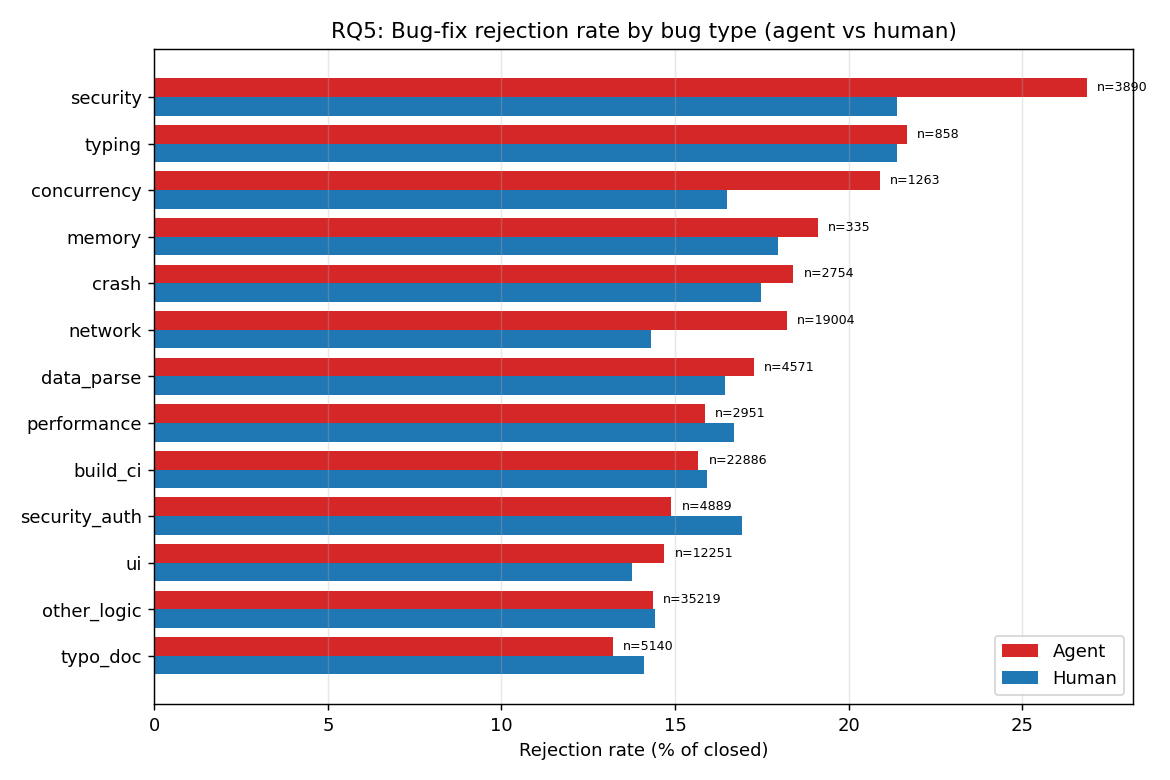

In [ ]:
meta = pd.read_parquet(os.path.join(DATA, "fix_prs_only.parquet"), columns=["id","title","body"])
df5 = prs.merge(meta, on="id", how="left")   # prs already has churn/has_test/closed/rejected/grp

CATS = [
 ("security",     r"\b(security|vulnerab\w*|cve-?\d|xss|csrf|sql\s*injection|injection|exploit|sanitiz)\b"),
 ("crash",        r"\b(crash\w*|segfault|seg\s*fault|npe|null\s*pointer|nullpointer|exception|panic|fatal|stack\s*overflow)\b"),
 ("concurrency",  r"\b(race\s*condition|deadlock|concurren\w*|thread[-\s]?safe\w*|mutex|data\s*race|atomic)\b"),
 ("memory",       r"\b(memory\s*leak|mem\s*leak|out\s*of\s*memory|oom|buffer\s*overflow|leak)\b"),
 ("performance",  r"\b(performance|perf|slow\w*|latency|speed\s*up|optimi[sz]\w*|throughput|timeout)\b"),
 ("security_auth",r"\b(authenticat\w*|authoriz\w*|permission|token|login|session)\b"),
 ("ui",           r"\b(ui|ux|css|layout|render\w*|display|styling|stylesheet|button|alignment|responsive|dark\s*mode)\b"),
 ("build_ci",     r"\b(build|ci|compil\w*|lint\w*|dependenc\w*|import\s*error|module\s*not\s*found|version\s*bump|packaging)\b"),
 ("typo_doc",     r"\b(typo|spelling|grammar|docstring|readme|documentation|docs)\b"),
 ("typing",       r"\b(type\s*error|typing|type\s*hint|mypy|type\s*annotation|typescript\s*type)\b"),
 ("data_parse",   r"\b(parse|parsing|serializ\w*|deserializ\w*|json|yaml|encoding|decod\w*|formatting)\b"),
 ("network",      r"\b(http|https|api|request|response|endpoint|url|websocket|socket|connection)\b"),
]
COMP = [(n, re.compile(p, re.I)) for n, p in CATS]
def classify(t, b):
    t = t if isinstance(t, str) else ""; b = b if isinstance(b, str) else ""
    txt = f"{t} {b[:300]}"
    for n, rx in COMP:
        if rx.search(txt): return n
    return "other_logic"
df5["btype"] = [classify(t, b) for t, b in zip(df5["title"], df5["body"])]

def by_type(df):
    d = df[df["closed"]]
    t = d.groupby("btype").agg(n=("id","size"), rej=("rejected","mean"), churn=("churn","median"))
    t["rej"] *= 100; return t
agt = by_type(df5[df5.grp=="Agent"]).sort_values("rej", ascending=False)
agt["human_rej"] = by_type(df5[df5.grp=="Human"])["rej"]
print(agt[["n","rej","churn","human_rej"]].round(1).to_string())

order = agt.index.tolist(); y = np.arange(len(order))
plt.figure(figsize=(9,6))
plt.barh(y-0.2, agt["rej"].values, height=0.4, label="Agent", color="#d62728")
plt.barh(y+0.2, agt["human_rej"].values, height=0.4, label="Human", color="#1f77b4")
for i in range(len(order)):
    plt.text(agt["rej"].iloc[i]+0.3, i-0.2, f"n={int(agt['n'].iloc[i])}", va="center", fontsize=7)
plt.yticks(y, order); plt.gca().invert_yaxis()
plt.xlabel("Rejection rate (% of closed)"); plt.title("RQ5: Bug-fix rejection rate by bug type (agent vs human)")
plt.legend(); plt.grid(axis="x", alpha=.3); plt.tight_layout(); plt.show()

## RQ6 (robustness) — Is "tests → more rejection" just a size confound?

Test-bearing PRs are far larger (**median churn 250 vs 15 lines**), and big PRs are harder to merge — so we re-check
the RQ6 effect *within* code-churn bins.

**Answer — size is a real co-factor but does NOT explain it away.** Within comparable-size bins, test PRs are still
rejected **+2.0 pts** more (size-weighted) — the effect is **robust**. (The lone `churn=0` bin is degenerate: only 5
test PRs; note that zero-churn *no-test* PRs are rejected most at 21.9% — these are the empty/agent-failed PRs.)

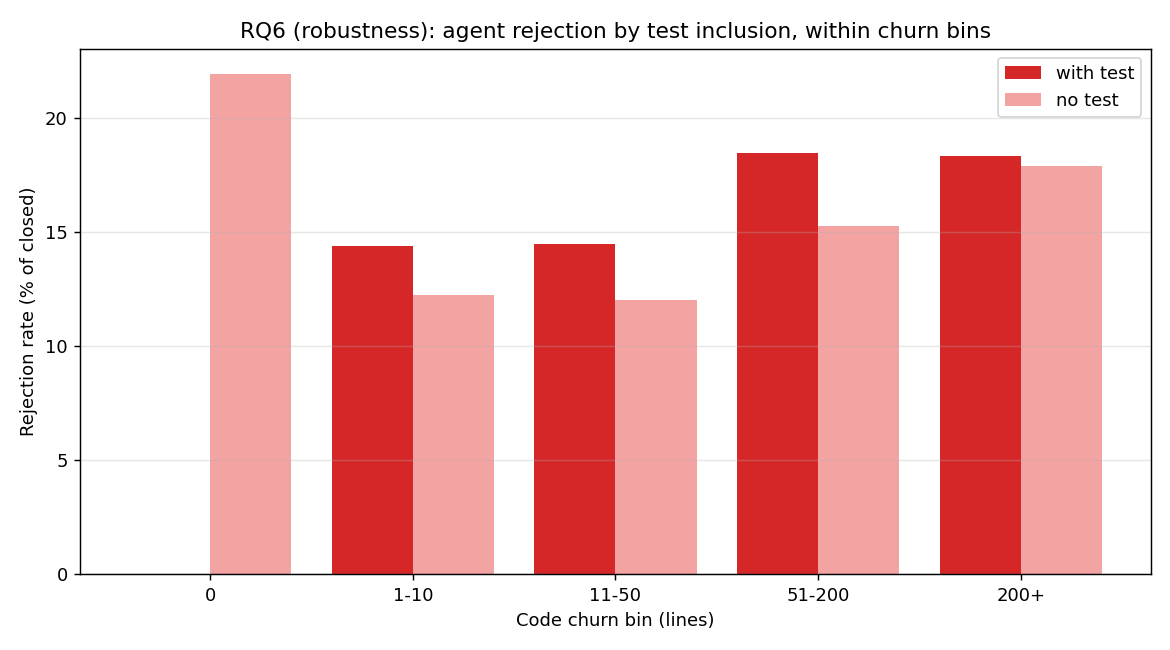

In [ ]:
a = prs[(prs.grp=="Agent") & prs["closed"]].copy()
print(f"median churn  with-test={a[a.has_test].churn.median():.0f}  no-test={a[~a.has_test].churn.median():.0f}")
bins = [-1,0,10,50,200,1e12]; lbls = ["0","1-10","11-50","51-200","200+"]
a["cb"] = pd.cut(a["churn"], bins=bins, labels=lbls)
rows = []
for b in lbls:
    sub = a[a["cb"]==b]
    rt = 100*sub[sub.has_test]["rejected"].mean(); nt = int(sub.has_test.sum())
    rn = 100*sub[~sub.has_test]["rejected"].mean(); nn = int((~sub.has_test).sum())
    rows.append((b,rt,nt,rn,nn)); print(f"churn {b:7s}: +test {rt:5.1f}% (n={nt:5d}) | no-test {rn:5.1f}% (n={nn:6d})")
valid = [(rt,nt,rn,nn) for (_,rt,nt,rn,nn) in rows if nt>=200 and nn>=200 and not(np.isnan(rt) or np.isnan(rn))]
tot = sum(nt+nn for _,nt,_,nn in valid)
wdiff = sum((rt-rn)*(nt+nn) for rt,nt,rn,nn in valid)/tot
print(f"size-weighted test gap (n>=200/side): {wdiff:+.1f} pts -> {'robust to size' if wdiff>=1 else 'size confound'}")

x = np.arange(len(lbls))
plt.figure(figsize=(9,5))
plt.bar(x-0.2, [r[1] for r in rows], width=0.4, label="with test", color="#d62728")
plt.bar(x+0.2, [r[3] for r in rows], width=0.4, label="no test", color="#f4a3a3")
plt.xticks(x, lbls); plt.xlabel("Code churn bin (lines)"); plt.ylabel("Rejection rate (% of closed)")
plt.title("RQ6 (robustness): agent rejection by test inclusion, within churn bins")
plt.legend(); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## Caveats & next steps

- **Full-dataset rejection ≈ 16%**, not the **46.41%** in the MSR paper: this dataset has **no `stars` column**,
  so the >100-star filter can't be reproduced. Treat these as a larger/different population (popular repos reject ~3× more).
- **No `comments` column** here, so the comment-effort metric is omitted (would need the GitHub API).
- **RQ2b/RQ4 limits:** relay only sees PRs with an explicit issue link (~18% coverage); revert detection is a PR-routed lower bound and is time-biased (agent fixes are younger).
- **RQ5 limit:** bug types come from a keyword heuristic on title/body (no issue labels); worth a manual-validation sample before publication.
- **Strongest contributions:** RQ2a (agent-switching over time), RQ1a (agent–human gap closing), RQ2b (substitution is rare), RQ4 (agent fixes durable), RQ5 (security/concurrency are agents' weak spots).